In [129]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import ast

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_rows', None) 
pd.set_option('display.max_columns', None) 

In [130]:
data = pd.read_csv('/Users/oguzhanerbil/Documents/Repolarım/food-health-predictor/data/data.csv')

In [131]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5702 entries, 0 to 5701
Data columns (total 26 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   barkod                      5702 non-null   int64  
 1   miktar                      5077 non-null   float64
 2   markalar                    5559 non-null   object 
 3   alerjenler                  5702 non-null   object 
 4   eser_miktarlar              5702 non-null   object 
 5   icerik_sayisi               5348 non-null   float64
 6   nutriscore_notu             5688 non-null   object 
 7   nova_grubu                  5068 non-null   float64
 8   yesil_skor_notu             4170 non-null   object 
 9   palmiye_yagi_icermez        5169 non-null   object 
 10  vejetaryen                  4905 non-null   object 
 11  vegan_durumu                5358 non-null   object 
 12  enerji_kcal                 5520 non-null   float64
 13  yag_g                       5519 

In [132]:
data.describe()

,barkod,miktar,icerik_sayisi,nova_grubu,enerji_kcal,yag_g,doymus_yag_g,karbonhidrat_g,seker_g,lif_g,protein_g,tuz_g,sodyum_g,alkol_yuzde,meyve_sebze_baklagil_yuzde
count,5.702000e+03,5077.000000,5348.000000,5068.000000,5520.000000,5519.000000,5474.000000,5515.000000,5476.000000,4564.000000,5519.000000,5597.000000,5470.000000,383.000000,1491.000000
mean,4.195864e+12,297.178201,8.962229,2.617009,198.114312,8.045639,1.246069,20.558341,3.121362,4.550521,9.279283,0.321087,0.130262,3.294332,20.451268
std,2.524986e+12,297.793564,10.026786,1.289206,199.536018,16.680632,2.259096,24.876067,3.953301,7.577317,12.282327,0.422302,0.169976,15.535225,45.748431
min,4.856900e+04,0.000000,1.000000,1.000000,0.000000,-0.880969,-0.126229,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.250392e+12,60.000000,2.000000,1.000000,55.000000,0.500000,0.100000,3.700000,0.300000,0.795000,2.000000,0.010000,0.004000,0.000000,0.000000
50%,3.580282e+12,250.000000,5.000000,3.000000,114.500000,2.000000,0.500000,8.300000,2.000000,3.000000,8.000000,0.100000,0.040000,0.000000,0.000000
75%,5.070000e+12,500.000000,14.000000,4.000000,347.000000,6.700000,1.300000,33.000000,4.400000,7.000000,13.000000,0.570000,0.232000,0.000000,10.482343
max,9.327007e+13,9000.000000,150.000000,4.000000,4000.000000,100.000000,21.666667,122.807018,65.000000,375.000000,690.700000,5.000000,2.000000,98.000000,449.400000


In [133]:
data.sample(5)

,barkod,miktar,markalar,alerjenler,eser_miktarlar,icerik_sayisi,nutriscore_notu,nova_grubu,yesil_skor_notu,palmiye_yagi_icermez,vejetaryen,vegan_durumu,enerji_kcal,yag_g,doymus_yag_g,karbonhidrat_g,seker_g,lif_g,protein_g,tuz_g,sodyum_g,alkol_yuzde,meyve_sebze_baklagil_yuzde,birim,kategori_listesi,etiketler_listesi
4074,3181238951047,240.0,charal,[],[],1.0,A,1.0,NaN,True,False,no,129.0,4.6,1.6,0.0,0.0,0.0,22.0,0.10,0.040,NaN,0.0,g,"['Meats and their products', 'Beef and its pro...","['Organic', 'EU Organic', 'French meat', '100%..."
45,4056489620938,500.0,lidl,['Peanuts'],['Soybeans'],1.0,A,1.0,D,True,True,yes,683.0,55.1,12.0,12.0,3.9,9.2,30.4,0.03,0.012,NaN,0.0,g,"['Plant-based foods and beverages', 'Plant-bas...",['Nutriscore']
3270,5000237204085,80.0,tyrell’s,[],"['Gluten', 'Soybeans']",30.0,A,4.0,NaN,True,True,yes,460.0,18.0,1.6,57.0,4.9,7.2,13.0,0.58,0.232,NaN,NaN,g,"['Snacks', 'Salty snacks', 'Appetizers', 'Chip...",[]
4772,3660088162556,165.0,la belle iloise,"['Fish', 'Gluten', 'Sulphur dioxide and sulphi...",[],19.0,B,3.0,NaN,True,False,no,140.0,5.6,0.9,16.0,2.2,0.0,8.0,0.90,0.360,0.0,NaN,g,"['Seafood', 'Fishes and their products', 'Fish...","['Triman', 'Without']"
4863,8414606606092,NaN,tradipan,['Gluten'],[],9.0,B,4.0,B,True,True,maybe,261.0,3.1,0.5,44.2,3.0,5.9,11.0,1.20,0.480,NaN,NaN,NaN,"['Plant-based foods and beverages', 'Plant-bas...","['Green Dot', 'No lactose']"


In [134]:
data.isnull().mean() * 100

barkod                         0.000000
miktar                        10.961066
markalar                       2.507892
alerjenler                     0.000000
eser_miktarlar                 0.000000
icerik_sayisi                  6.208348
nutriscore_notu                0.245528
nova_grubu                    11.118906
yesil_skor_notu               26.867766
palmiye_yagi_icermez           9.347597
vejetaryen                    13.977552
vegan_durumu                   6.032971
enerji_kcal                    3.191863
yag_g                          3.209400
doymus_yag_g                   3.998597
karbonhidrat_g                 3.279551
seker_g                        3.963522
lif_g                         19.957910
protein_g                      3.209400
tuz_g                          1.841459
sodyum_g                       4.068748
alkol_yuzde                   93.283059
meyve_sebze_baklagil_yuzde    73.851280
birim                         12.907752
kategori_listesi               0.000000


In [135]:
for column in data.columns:
    unique_values = data[column].astype(str).unique()
    unique_values_str = sorted(list(unique_values))
    n = 10
    displayed_values = unique_values_str[:n]
    print(f"{column} ({len(unique_values_str)}): {displayed_values}{' ...' if len(unique_values_str) > n else ''}")

barkod (5702): ['10001219', '10001400', '10015599', '10089149', '10096376', '10100295', '10217603', '10254899', '10677964', '11110016508'] ...
miktar (321): ['0.0', '0.07', '0.095', '0.1', '0.112', '0.125', '0.14', '0.15', '0.18', '0.2'] ...
markalar (1760): ['07x netto 03.25', '10dh', '166', '2keep', '365 whole foods market', '3bears', '5 fruits', '7 up', 'abatilles', "abbot kinney's"] ...
alerjenler (305): ["['Apple', 'Gluten', 'Gluten', 'Gluten']", "['Apple', 'Milk', 'Milk']", "['Apple']", "['Avoine']", "['Banana']", "['Beef', 'Gluten', 'Milk', 'Pork', 'Sulphur dioxide and sulphites']", "['Beef', 'Gluten', 'Sesame seeds', 'Soybeans']", "['Beef', 'Milk', 'Pork']", "['Beef']", "['Celery', 'Chicken', 'Eggs', 'Gluten', 'Milk', 'Soybeans']"] ...
eser_miktarlar (478): ["['Agua']", "['Basil-oil', 'Pesticides']", "['Celery', 'Crustaceans', 'Eggs', 'Fish', 'Gluten', 'Lupin', 'Milk', 'Molluscs', 'Mustard', 'Nuts', 'Peanuts', 'Sesame seeds', 'Soybeans', 'Sulphur dioxide and sulphites']", "['Ce

In [136]:
df = data.copy()

def convert_to_list(x):
    if pd.isna(x):
        return []
    if isinstance(x, list):
        return x
    if isinstance(x, str):
        s = x.strip()
        if s == "":
            return []
        try:
            val = ast.literal_eval(s)
            return val if isinstance(val, list) else [val]
        except:
            return [p.strip() for p in s.split(',') if p.strip()]
    return []

for col in ['eser_miktarlar','kategori_listesi','alerjenler','etiketler_listesi',"markalar"]:
    s = df[col].apply(convert_to_list).explode().dropna().astype(str)
    s = s[s != '']
    counts = s.value_counts()
    print(f"--- {col} - Top 50 ---")
    print(counts.head(50))
    print(f"\nToplam Benzersiz {col}: {len(counts)}\n")


--- eser_miktarlar - Top 50 ---
eser_miktarlar
Soybeans                                                                    842
Nuts                                                                        696
Milk                                                                        611
Gluten                                                                      501
Sesame seeds                                                                498
Mustard                                                                     455
Eggs                                                                        441
Celery                                                                      312
Peanuts                                                                     207
Lupin                                                                       122
Fish                                                                        100
Crustaceans                                                              

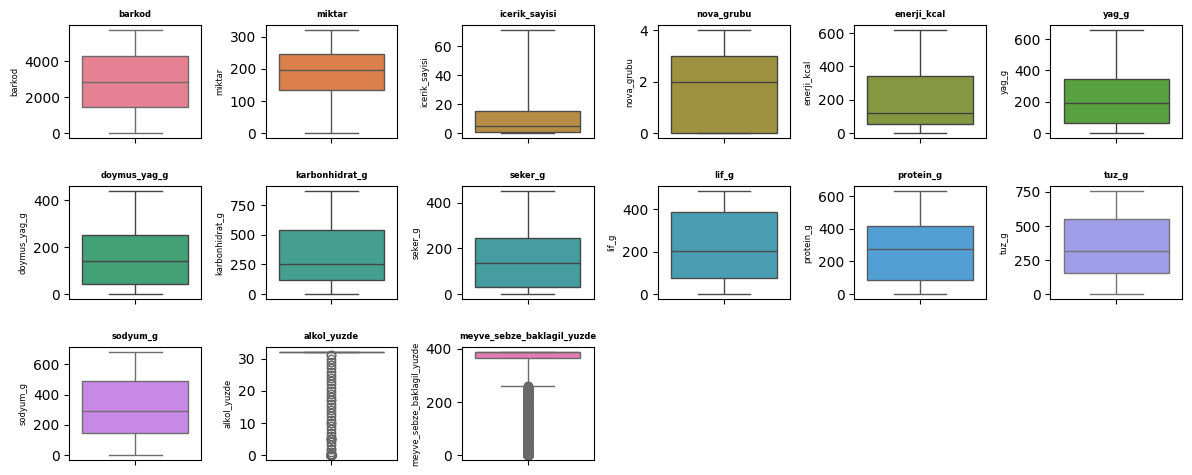

In [137]:
from sklearn.calibration import LabelEncoder
import seaborn as sns

veri = data.copy()

selected_columns = veri.select_dtypes(include=['number']).columns.tolist()

label_encoder = LabelEncoder()

for column in selected_columns:
    veri[column] = label_encoder.fit_transform(veri[column])

# Plot sayısını belirleyip subplotları ayarlayalım
fig, axes = plt.subplots(nrows=int(np.ceil(len(selected_columns)/3)), ncols=6, figsize=(12, 1 * int(np.ceil(len(selected_columns)/2))))

# Renk paleti seçimi
palette = sns.color_palette("husl", len(selected_columns))

# Boxplotları çizelim
axes = axes.flatten()
for i, col in enumerate(selected_columns):
    sns.boxplot(y=col, data=veri, ax=axes[i], color=palette[i], whis=5)
    axes[i].set_title(f'{col}', fontsize=6, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel(col, fontsize=6)

# Kullanılmayan subplotları kaldıralım
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

# Grafik düzenini iyileştirelim
plt.tight_layout(pad=1.0, w_pad=1.0, h_pad=2.0)
plt.show()

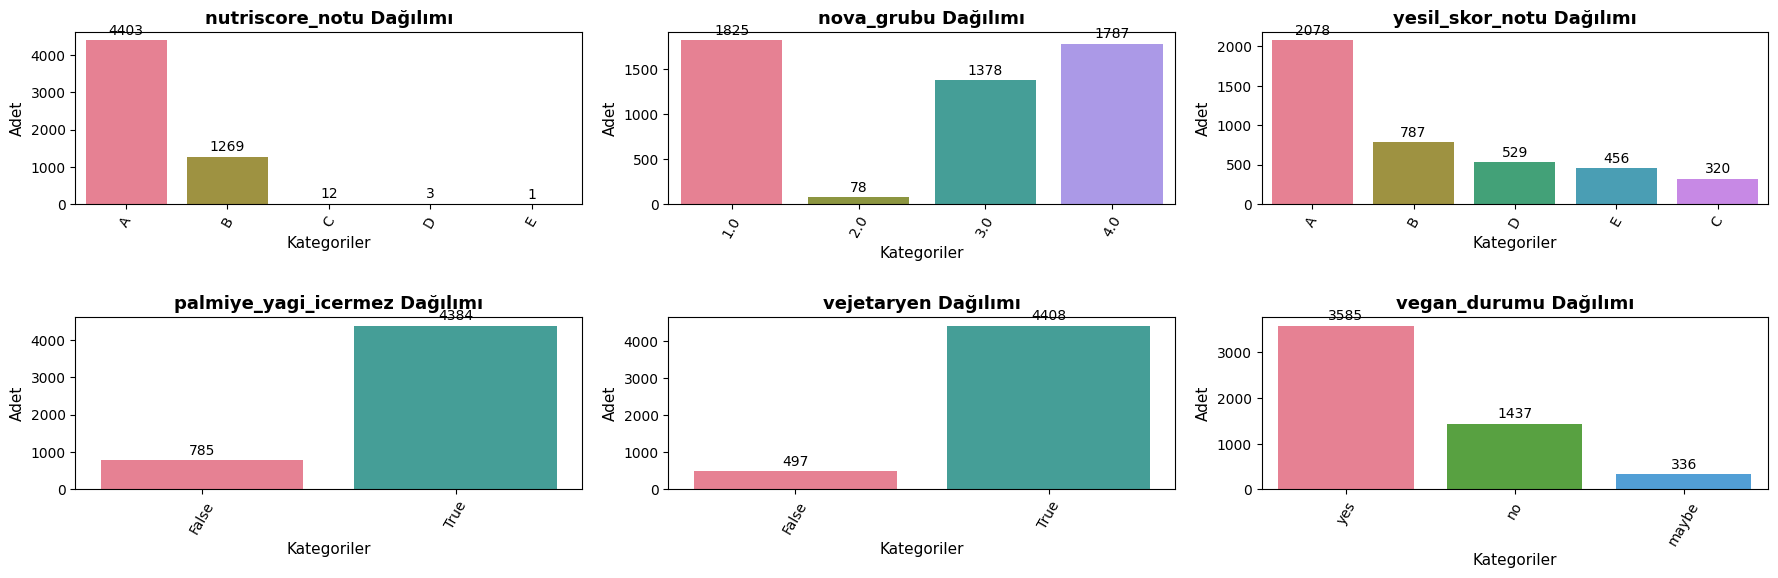

In [138]:
unique_counts = data.nunique()

categorical_columns = unique_counts[unique_counts <= 20].index.tolist()

n_cols = 3
n_rows = int(np.ceil(len(categorical_columns) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*6, n_rows*3))
axes = axes.flatten()

for i, column in enumerate(categorical_columns):
    val_counts = data[column].value_counts()
    sns.barplot(x=val_counts.index, y=val_counts.values, ax=axes[i], palette='husl')
    axes[i].set_title(f'{column} Dağılımı', fontsize=13, fontweight='bold')
    axes[i].set_xlabel("Kategoriler", fontsize=11)
    axes[i].set_ylabel("Adet", fontsize=11)
    axes[i].tick_params(axis='x', rotation=60)

    # Her sütunun üzerine değerleri ekleyelim
    for p in axes[i].patches:
        axes[i].annotate(format(p.get_height(), '.0f'), 
                         (p.get_x() + p.get_width() / 2., p.get_height()),
                         ha='center', va='center', fontsize=10, color='black', xytext=(0, 7),
                         textcoords='offset points')

# Kullanılmayan subplotları kaldıralım
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout(pad=1.5, w_pad=1.5, h_pad=2.5)
plt.show()